In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX rendering (requires LaTeX installed)
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 10              # Set all text to 12 pt
})

from itertools import combinations, permutations

def factorial(N):
    return np.prod(np.arange(1,N+1, 1))

def euclid_distance(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    takes two points p1, p2 as two ndarrays of length d (d: dimension) 
    and calculates the euclidean distance between the two points
    returns distance as float value
    """
    return np.sqrt(np.sum(np.square(p1 - p2)))

def tsp_length(nodes_array: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    
    :param nodes_array: (sorted) array of coordinates of the N nodes
    :type nodes_array: np.ndarray (N, d)
    :return: total traveling distance
    :rtype: float
    """
    # calculate the pairwise differences between two consecutive nodes, keep in mind to return to start
    differences = nodes_array - np.roll(nodes_array, shift=-1, axis=0)
    # calculate individual distances and sum up
    distances = np.sqrt(np.sum(np.square(differences), axis=1))
    return np.sum(distances)

def polar_to_cartesian(r: float, theta: float) -> np.ndarray:
    """
    convert polar coordinates to cartesian coordinates
    
    :param r: radius
    :type r: float
    :param theta: angle in radians
    :type theta: float
    :return: cartesian coordinates as ndarray [x, y]
    :rtype: np.ndarray
    """
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def cartesian_to_polar(x: float, y: float) -> np.ndarray:
    """
    convert cartesian coordinates to polar coordinates
    
    :param x: x coordinate
    :type x: float
    :param y: y coordinate
    :type y: float
    :return: polar coordinates as ndarray [r, theta]
    :rtype: np.ndarray
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return np.column_stack([r, theta])

def tsp_length_from_dist_matrix(distance_matrix: np.ndarray, permutation: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    given the distance matrix D and the current permutation
    
    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)
    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)
    :return: total traveling distance
    :rtype: float
    """
    # sum distances between consecutive nodes (equation 3 in Cerny 1985)
    d = np.sum(distance_matrix[permutation[:-1], permutation[1:]])
    # add distance from last node back to first
    d += distance_matrix[permutation[-1], permutation[0]]
    return d

def metric_time_dep(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: int = 5,
    traffic_jam_area: np.ndarray = None,
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """

    if traffic_jam_area is None:
        traffic_jam_area = np.array([[0, 1], [0, 1]])

    def eta(i: int) -> int:
        """determine if node i and node i + 1 are within the traffic jam area"""
        x1, y1 = node_coordinates[permutation[i]]
        x2, y2 = node_coordinates[permutation[(i + 1) % len(permutation)]]

        inside1 = (traffic_jam_area[0, 0] <= x1 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y1 <= traffic_jam_area[1, 1])
        inside2 = (traffic_jam_area[0, 0] <= x2 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y2 <= traffic_jam_area[1, 1])

        return int(inside1 and inside2)

    def xi(i: int) -> float:
        """calculate the inner Heaviside helper function xi"""
        s = 0.0
        for j in range(i):
            s += distance_matrix[permutation[j],
                                 permutation[(j + 1) % len(permutation)]]
        return s - M

    def correction_term(i: int) -> float:
        """calculate traffic jam correction term"""
        denom = distance_matrix[permutation[i],
                                permutation[(i + 1) % len(permutation)]]
        if denom == 0:
            return 0.0  # avoid division by zero

        return (
            np.heaviside(xi(i), 1)
            * (1 - np.heaviside(xi(i - 1), 1))
            * xi(i)
            / denom
        )

    # calculate the metric
    distance = 0.0
    n = len(permutation)

    for i in range(n):
        base = distance_matrix[permutation[i],
                               permutation[(i + 1) % n]]

        distance += base * (
            1
            + eta(i)
            * (f - 1)
            * (np.heaviside(xi(i - 1), 1) + correction_term(i))
        )

    return float(distance)

def metric_time_dep_vectorized(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: float = 5.0,
    traffic_jam_area: np.ndarray = np.array([[0, 1], [0, 1]]),
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """
        
    n = len(permutation)

    # --- 1. tour edges (i -> i+1) ---
    i_idx = permutation
    j_idx = permutation[np.roll(np.arange(n), +1)]

    edge_distances = distance_matrix[i_idx, j_idx]   # shape (n,)

    # --- 2. eta(i): both nodes in jam area ---
    coords_i = node_coordinates[i_idx]
    coords_j = node_coordinates[j_idx]

    in_area_i = (
        (traffic_jam_area[0, 0] <= coords_i[:, 0]) &
        (coords_i[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_i[:, 1]) &
        (coords_i[:, 1] <= traffic_jam_area[1, 1])
    )

    in_area_j = (
        (traffic_jam_area[0, 0] <= coords_j[:, 0]) &
        (coords_j[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_j[:, 1]) &
        (coords_j[:, 1] <= traffic_jam_area[1, 1])
    )

    eta = in_area_i & in_area_j
    eta = eta.astype(float)

    # --- 3. cumulative distance Xi(i) ---
    # Xi(i) = total distance traveled before edge i minus M
    cumulative_dist = np.cumsum(edge_distances)
    xi = cumulative_dist - M

    # shift version for xi(i-1)
    xi_prev = np.roll(xi, 1)

    # --- 4. Heaviside ---
    H_xi = np.heaviside(xi, 1)
    H_prev = np.heaviside(xi_prev, 1)

    # --- 5. Correction term ---
    # avoid divide-by-zero
    denom = np.where(edge_distances == 0, 1e-12, edge_distances)

    correction = H_xi * (1 - H_prev) * xi / denom

    # --- 6. Final time-dependent metric ---
    distance = np.sum(
        edge_distances
        * (
            1
            + eta * (f - 1) * (H_prev + correction)
        )
    )

    return float(distance)



In [2]:
# define N nodes, uniformly spaced around a circle
N = 8
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# brute force TSP solution
# always start and end at node 0
# get all permutations of the nodes excluding the first one
node_indices = np.arange(N)
perms = permutations(node_indices)
tours = nodes[np.array([[0] + list(p) + [0] for p in perms])]
lengths = np.array([tsp_length(tour) for tour in tours])




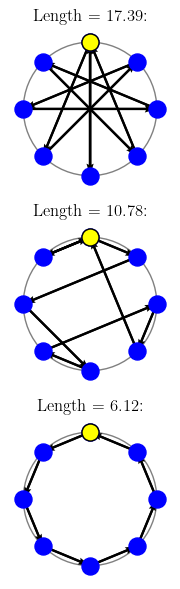

In [3]:
# best / worst / random indices
min_index = np.argmin(lengths)
min_length = lengths[min_index]
max_index = np.argmax(lengths)

# choose a random tour that is not min or max
all_indices = np.arange(len(tours))
valid_indices = np.delete(all_indices, [min_index, max_index])
random_tour_idx = np.random.choice(valid_indices)

# create subplots
fig, ax = plt.subplots(3, 1, figsize=(3.4, 6))

for i, idx in enumerate([max_index, random_tour_idx, min_index]):
    tour = tours[idx]

    # axis settings
    ax[i].set_aspect('equal')
    ax[i].axis('off')
    ax[i].grid(False)

    ax[i].set_ylim(-1.2, 1.2)
    ax[i].set_xlim(-1.2, 1.2)

    # draw circle
    circle = plt.Circle((0, 0), R, color='gray', fill=False)
    ax[i].add_artist(circle)

    # nodes
    ax[i].scatter(nodes[:, 0], nodes[:, 1], color='blue', s=150, zorder=3)

    # highlight start node
    ax[i].scatter(nodes[0, 0], nodes[0, 1],
                  color='yellow', edgecolors='black', s=150, zorder=3)

    # plot path
    ax[i].plot(tour[:, 0], tour[:, 1], 'k-')

    # arrows
    dx = np.diff(tour[:, 0])
    dy = np.diff(tour[:, 1])

    ax[i].quiver(
        tour[:-1, 0], tour[:-1, 1],
        dx, dy,
        angles='xy', scale_units='xy', scale=1,
        color='black', width=0.015, zorder=1
    )

    # optional title
    ax[i].set_title(f"Length = {lengths[idx]:.2f}: ")

plt.tight_layout()
plt.savefig('brute_force_tsp_8_nodes.pdf')
plt.show()


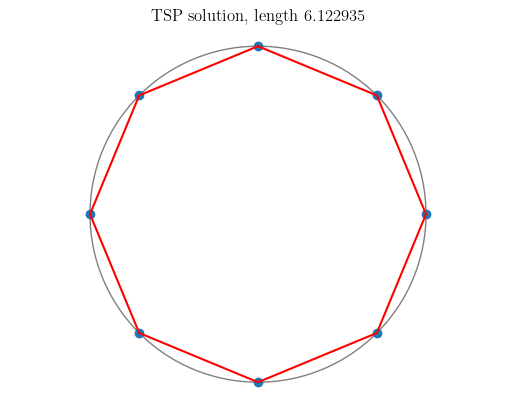

In [4]:
# plot results
plt.figure()
plt.title(f"TSP solution, length {min_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1])
plt.plot(tours[min_index][:, 0], tours[min_index][:, 1], 'r-')
plt.show()

want_a_lot_of_plots = False
if want_a_lot_of_plots:
    for tour in tours[::]:
        plt.figure()
        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        circle = plt.Circle((0, 0), R, color='gray', fill=False)
        plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1])
        plt.plot(tour[:, 0], tour[:, 1], 'b-', alpha=0.1)
    plt.show()

## Monte-Carlo simulating an approximative TSP result

In [70]:
# implement algorithm
def simulated_annealing(nodes : np.ndarray, start_point_index = 0, temperatures = [0.1, 0.05, 0.01, 0.001], convergence = [20, 200, 2000, 10000], max_repetitions_per_T = 100000, want_plot=True) -> None:
    """
    simulated annealing algorithm for the stationary traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param start_point: indice of start and end point coordinates
    :type start_point: indice

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param convergence: list of rejection steps in a row per temperature
    :type convergence: list

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean
    
    :return: None
    """

    if len(temperatures) != len(convergence):
        raise Exception('The array temperatures and convergence need to have the same length')

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation and place starting_point_index in the front (w/o duplicates)
    if start_point_index != None:
        starting_perm = np.concatenate((np.array([start_point_index]), np.random.permutation(np.arange(N)[np.arange(N) != start_point_index])))
    else:
        starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []   # length array for convergence plot

    current_perm = starting_perm.copy()
    current_length = tsp_length_from_dist_matrix(D, current_perm)

    temperature_step = 0  # for loading bar
    rejection_count = 0   # convergence criterium
    repetitions_arr = []  # repetitions for each temperature calculated, for plotting
    for temperature in temperatures:
        repetition_count = 0
        while rejection_count < convergence[temperature_step] and repetition_count < max_repetitions_per_T:
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # enforce start_point_index to be in the front again
                if start_point_index != None:
                    trial_perm = np.concatenate((np.array([start_point_index]), trial_perm[trial_perm != start_point_index]))
                
                # calculate corresponding length
                trial_length = tsp_length_from_dist_matrix(D, trial_perm)

                # accept reject step
                if trial_length < current_length:  # accept
                    current_perm = trial_perm.copy()
                    current_length = trial_length

                    rejection_count = 0  # reset rejection counter

                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):  # accept still with boltzman probability
                        current_perm = trial_perm.copy()
                        current_length = trial_length 

                        rejection_count = 0  # reset rejection counter

                    else:  # reject
                        rejection_count += 1  # count up rejection counter

                length_arr.append(current_length)

                repetition_count += 1

            # loading bar
            # fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            fraction = (temperature_step) / (len(temperatures))
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        
        repetitions_arr.append(len(length_arr))
        temperature_step += 1



    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # circle = plt.Circle((0, 0), R, color='gray', fill=False)
        # plt.gca().add_artist(circle)
        plt.scatter(nodes[start_point_index, 0], nodes[start_point_index, 1], s=200, marker='s', color='yellow', edgecolors='black')
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for (i, repetition) in enumerate(repetitions_arr):
            plt.plot([repetition, repetition], [0, max(length_arr)], alpha = 0.4, color='grey') #, label=rf'{temperature[i]} $$\unit{{\kelvin}}$$')
        plt.plot(length_arr, color='black', label='TSP Length')
        # plt.xlim(0.99*len(length_arr), len(length_arr))
        # plt.ylim(6, 13)

        plt.xlabel('Iteration')
        plt.ylabel('TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()

        print(repetitions_arr)

    return

Annealing progress: |==============================----------| 75.00% Complete (T=0.001)

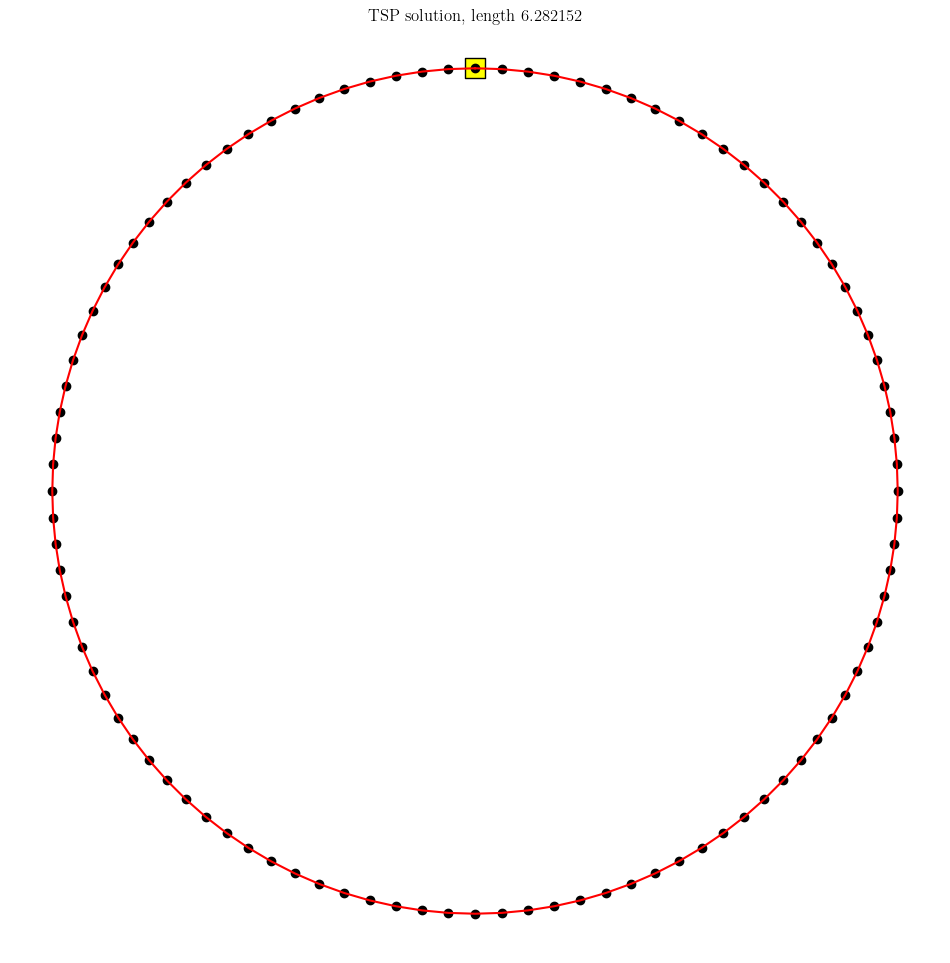

[25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20
 21 22 23 24]


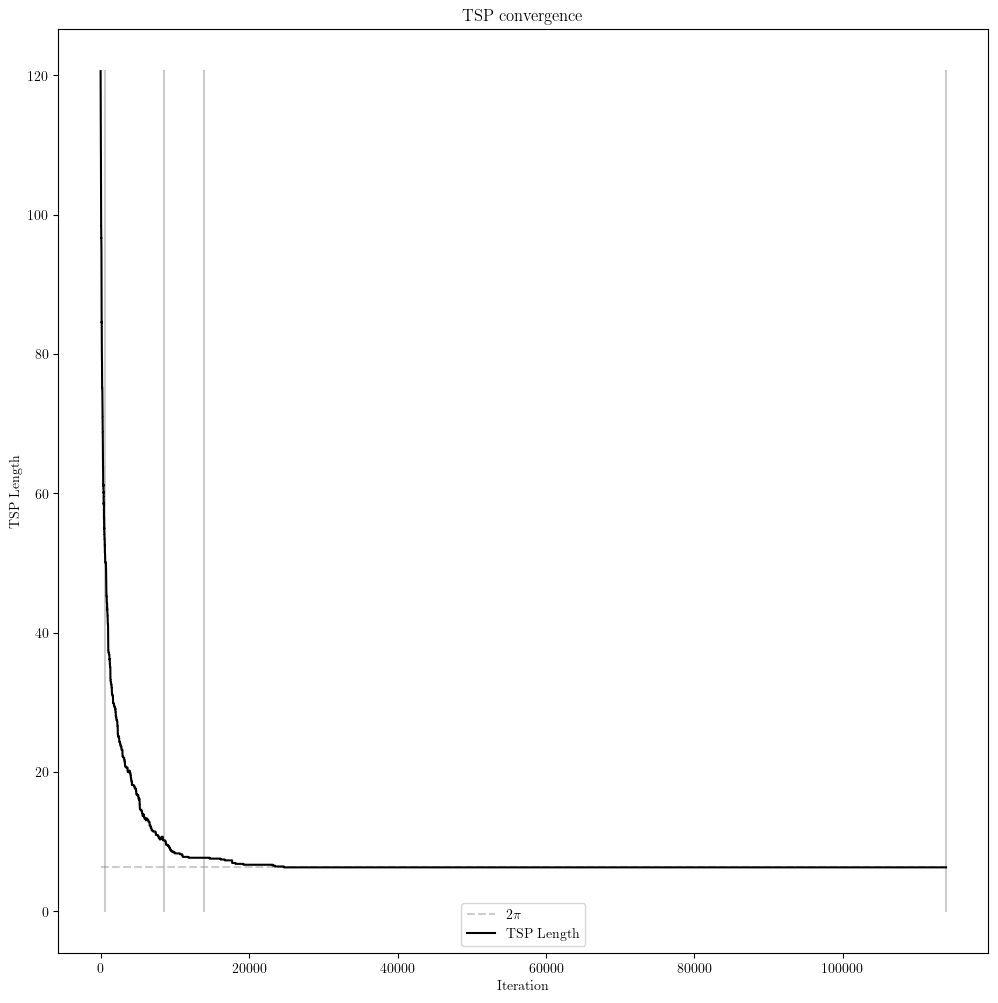

[600, 8600, 13900, 113900]


In [58]:
# generating points
# define N nodes, uniformly spaced around a circle
N = 100
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

simulated_annealing(nodes=nodes, start_point_index=25)


Annealing progress: |==============================----------| 75.00% Complete (T=0.001)

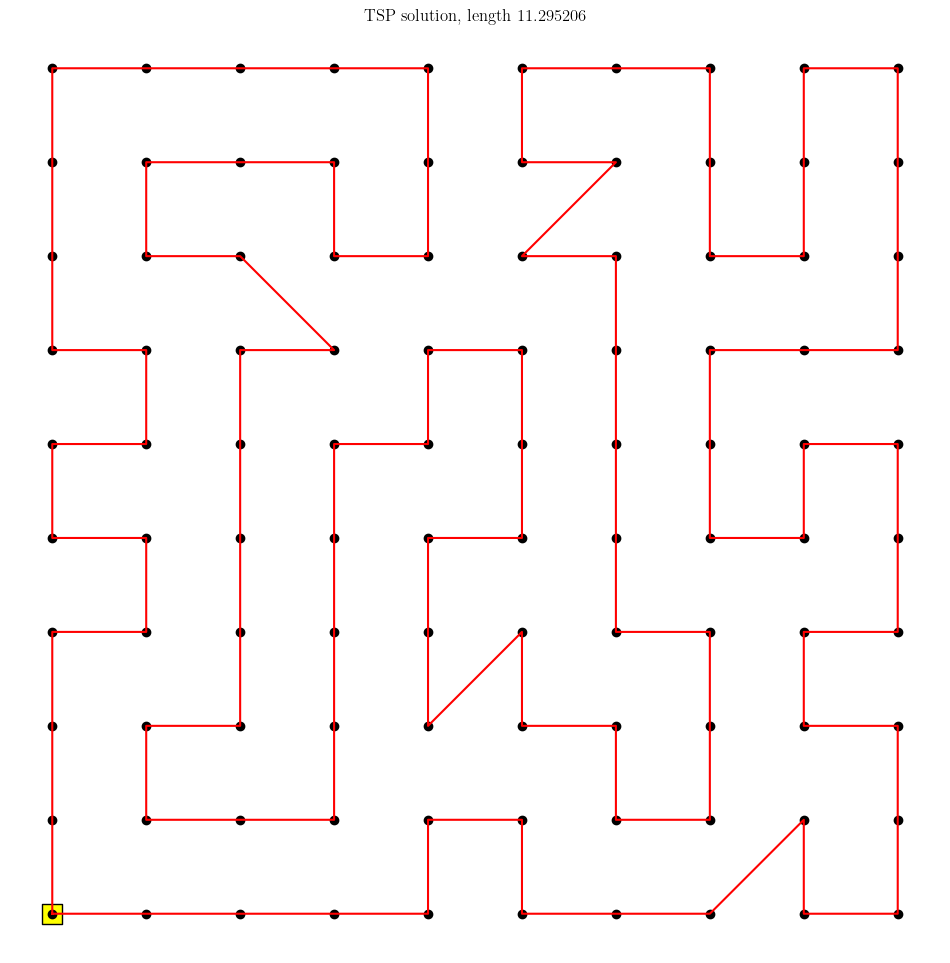

[ 0 10 20 30 31 41 40 50 51 61 60 70 80 90 91 92 93 94 84 74 73 83 82 81
 71 72 63 62 52 42 32 22 21 11 12 13 23 33 43 53 54 64 65 55 45 44 34 24
 35 25 26 16 17 27 37 36 46 56 66 76 75 86 85 95 96 97 87 77 78 88 98 99
 89 79 69 68 67 57 47 48 58 59 49 39 38 28 29 19  9  8 18  7  6  5 15 14
  4  3  2  1]


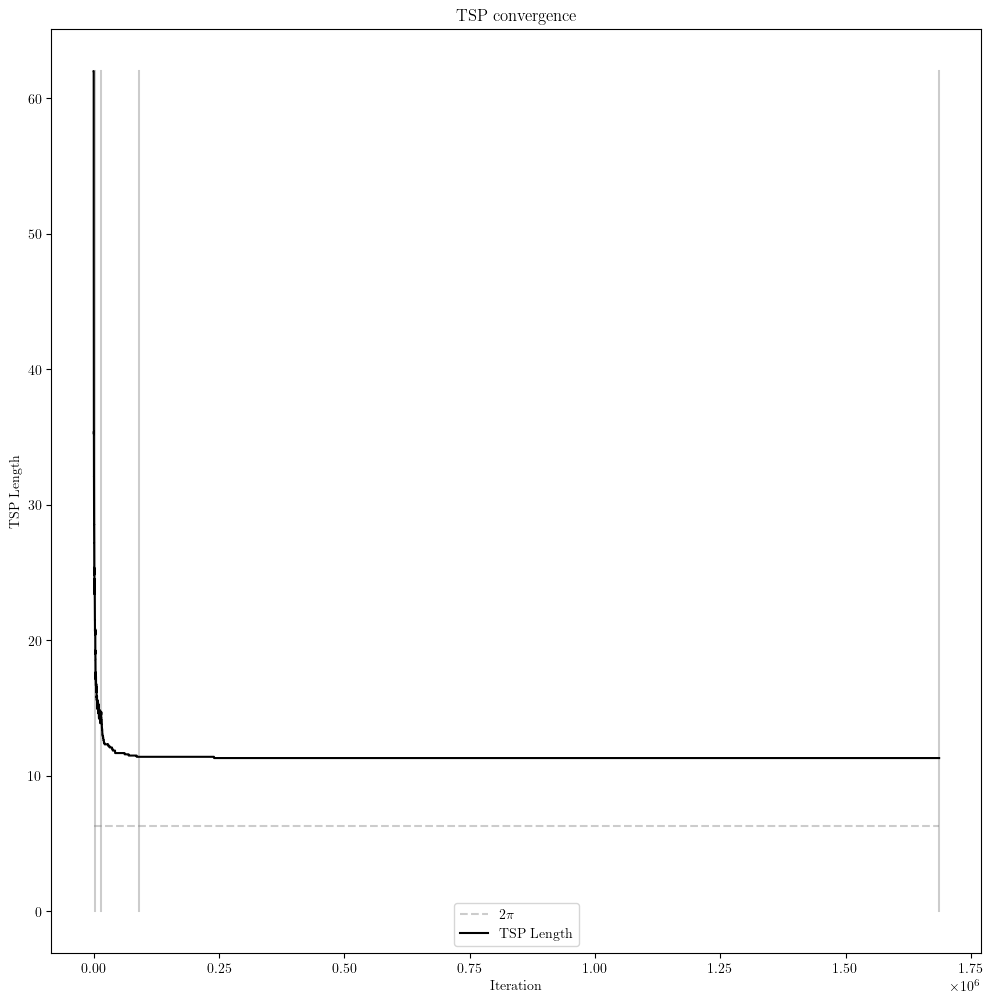

[2000, 15300, 90800, 1686600]
Annealing progress: |==============================----------| 75.00% Complete (T=0.001)

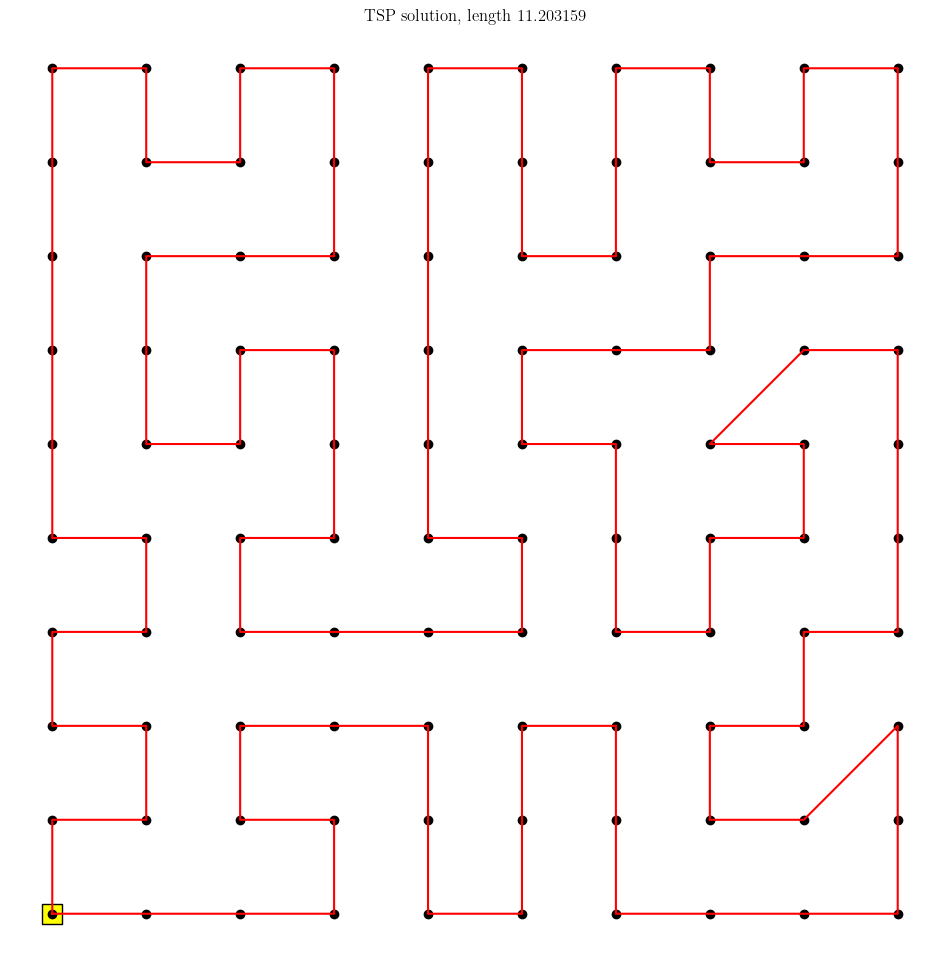

[ 0 10 11 21 20 30 31 41 40 50 60 70 80 90 91 81 82 92 93 83 73 72 71 61
 51 52 62 63 53 43 42 32 33 34 35 45 44 54 64 74 84 94 95 85 75 76 86 96
 97 87 88 98 99 89 79 78 77 67 66 65 55 56 46 36 37 47 48 58 57 68 69 59
 49 39 38 28 27 17 18 29 19  9  8  7  6 16 26 25 15  5  4 14 24 23 22 12
 13  3  2  1]


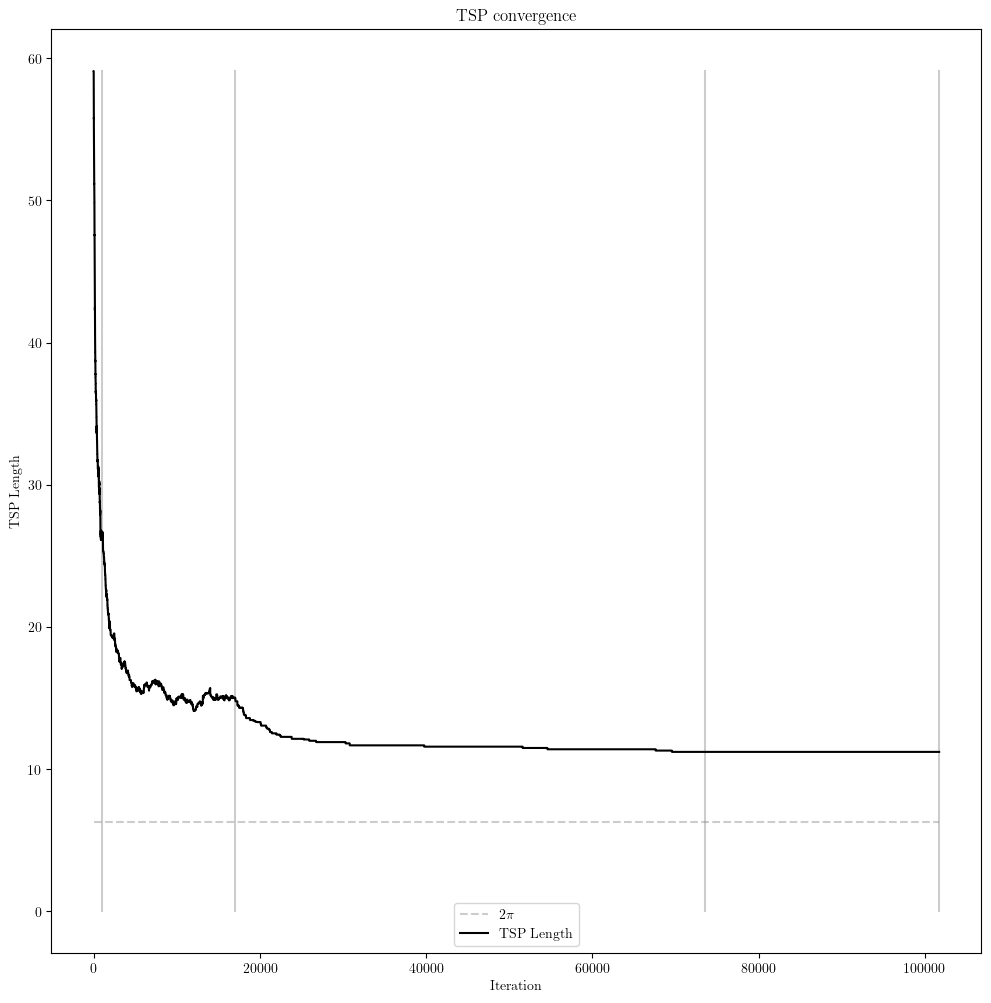

[1000, 17000, 73500, 101700]


In [71]:
# second example 
# N points aranged on a grid
sqrt_N = 10
N = np.square(sqrt_N)

x = np.linspace(0, 1, sqrt_N)
y = np.linspace(0, 1, sqrt_N)
X, Y = np.meshgrid(x, y)
nodes = np.column_stack([X.flatten(), Y.flatten()])
simulated_annealing(nodes=nodes, convergence=[20, 200, 2000, 4000], max_repetitions_per_T=1e7)
simulated_annealing(nodes=nodes, convergence=[20, 200, 2000, 4000], max_repetitions_per_T=1e7)


Annealing progress: |==============================----------| 75.00% Complete (T=0.001)

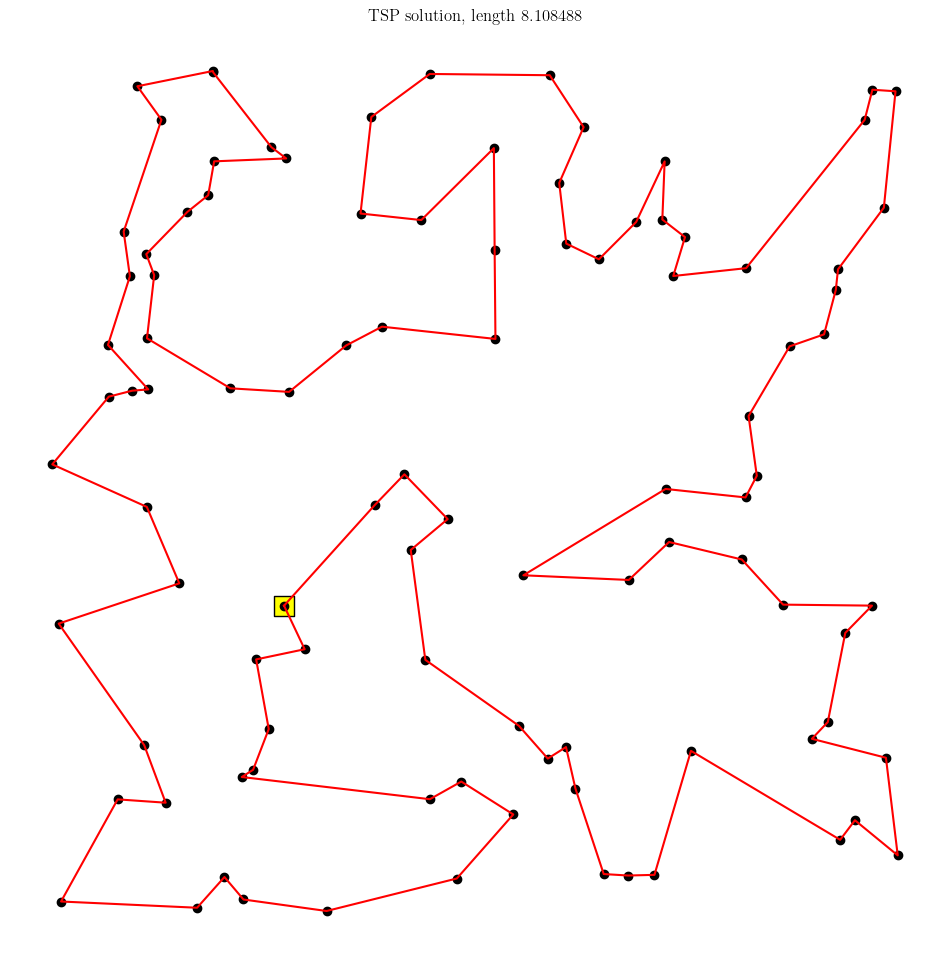

[ 0 46 33 94 29  8 13 22 68 61 84 48 60 10 58 79 80 67 18  7 37 30 97 57
 14 40 45  9 96 38 93 53 39 71 56 90 19 31 51 63 41 66  3 81 12 73  6 26
 44 54 27 34 99 50 21 11 76  5 69 74 49 43 86  4 75 65 85 87 70 15 89 88
 28 32 36 77 62 42 55 82 95 23 17 25 98 83 72 24  2 64 59 78 16 47 92 35
 20  1 52 91]


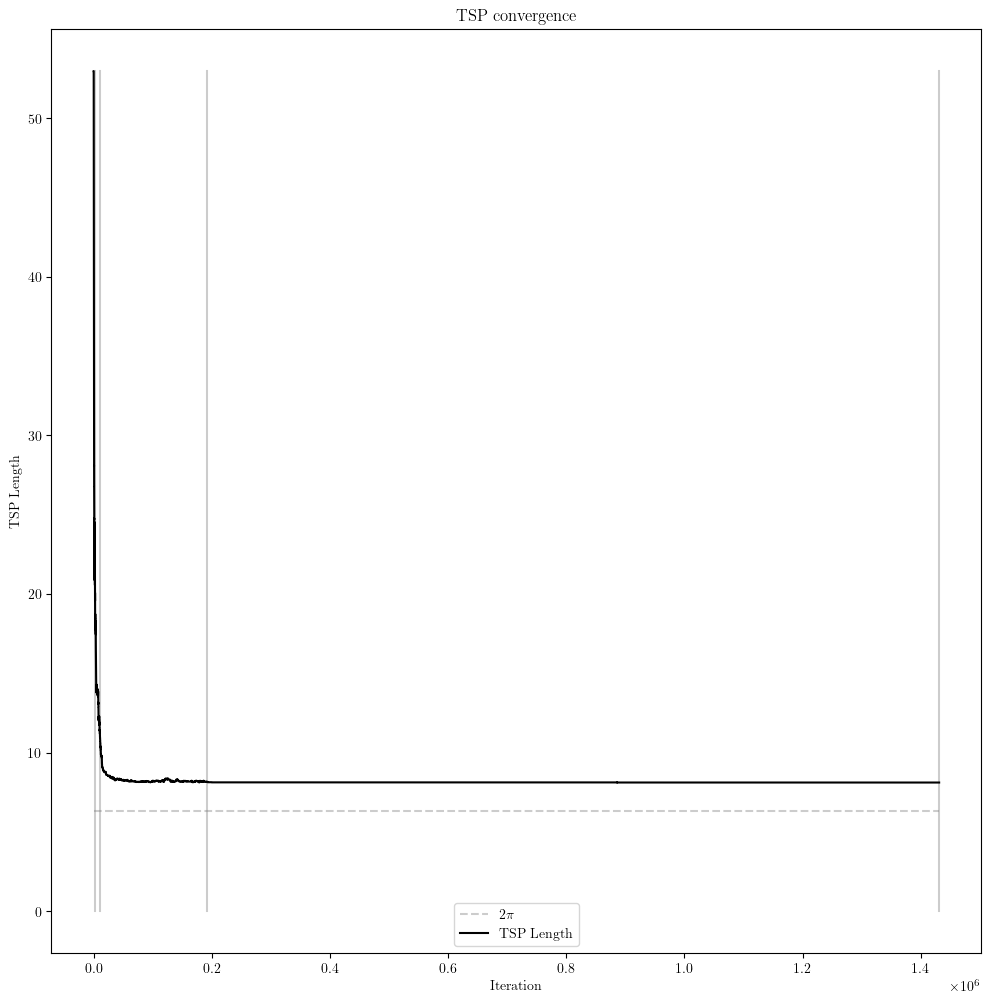

[2700, 10500, 192400, 1431200]


In [65]:
# third example
# N random points in a unit square
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes = np.column_stack([x, y])
simulated_annealing(nodes=nodes, convergence=[20, 200, 2000, 10000], max_repetitions_per_T=1e7)

Annealing progress: |==============================----------| 75.00% Complete (T=0.001)

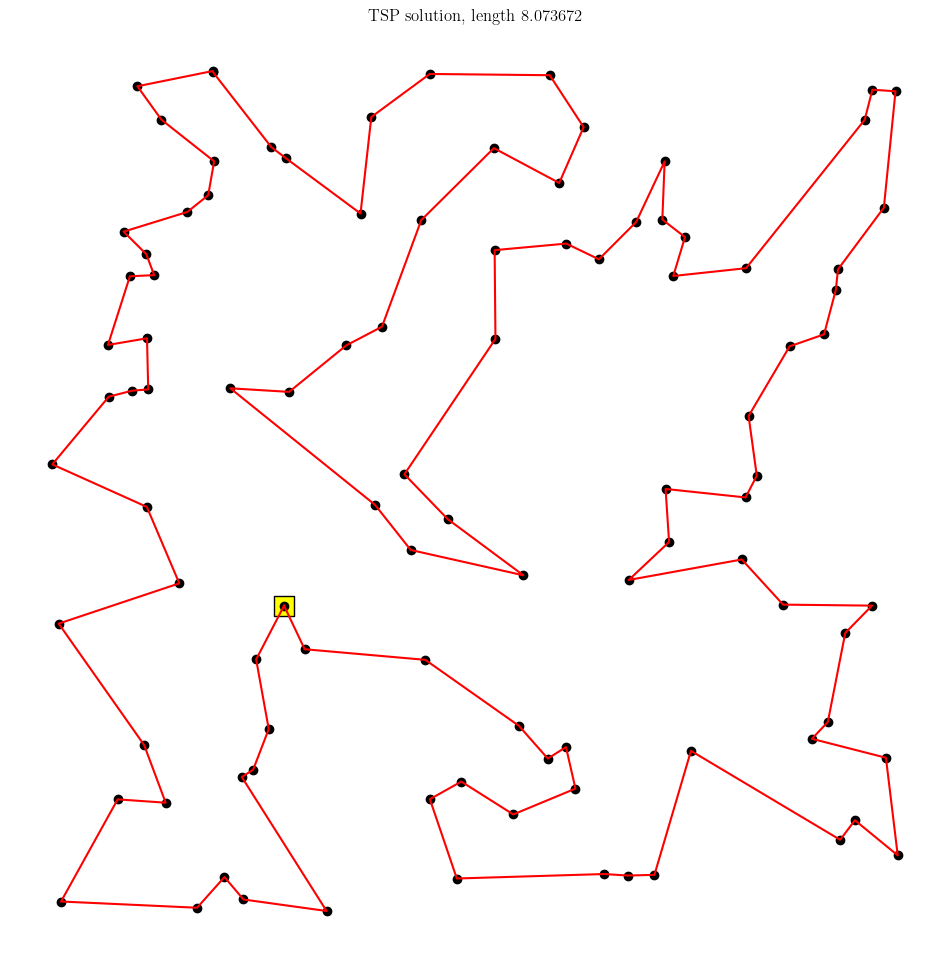

[ 0 52  1 20 35 59 64  2 24 72 83 98 25 17 23 95 82 55 42 62 43 77 36 86
  4 32 75 65 85 28 88 89 15 70 87 99 34 27 54 44 26 21 50  5 69 74 49 46
 29 45 94 33 76 11  6 73 12 81  3 66 41 63 51 31 19 90 56 71 39 53 93 38
 96  9 14 40 57 97 30 37  7 18 67 80 79 58 10 60 48 84 78 92 47 16 61 68
 22 13  8 91]


C:\Users\steff\AppData\Local\Temp\ipykernel_25176\497394371.py:131: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('tsp_sim_annealing_convergence.pdf')
C:\Users\steff\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


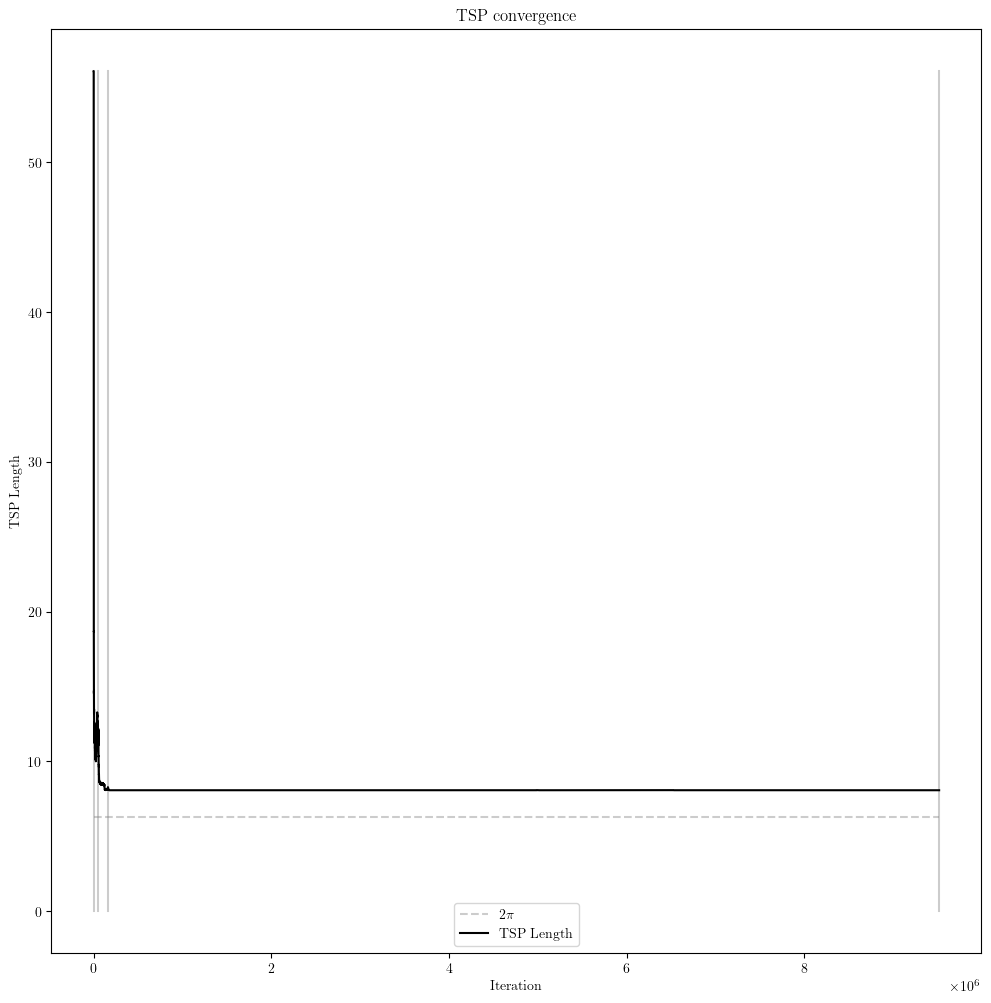

[1000, 53700, 164900, 9516300]


In [67]:
simulated_annealing(nodes=nodes, convergence=[20, 200, 2000, 10000], max_repetitions_per_T=1e7)

To increase convergance we implement second permutation step (Cerny, 1985)


In [ ]:
# implement algorithm
def simulated_annealing_improved(nodes : np.ndarray, temperatures = [0.1, 0.05, 0.025, 0.01, 0.005, 0.0025, 0.001, 0.0001], improved_permuation_step_n : int = 7, repetitions = 10000, want_plot=True) -> None:
    """
    simulated annealing algorithm for the stationary traveling salesman problem,
    with improved permutation step at the improved_permuation_step_n's temperature iteration

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param improved_permuation_step_n: step at which the improved permutation step is supposed to be used
    ideally at a temperature close to 0
    :type improved_permuation_step_n: integer

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = tsp_length_from_dist_matrix(D, current_perm)

    temperature_step = 0
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):

                if temperature_step < improved_permuation_step_n:
                    # sample j from 0 to N-1 with j=!i
                    choices = np.arange(N)
                    j = np.random.choice(choices[choices != i])
                else:
                    m = N / 2  # define m to be larger n
                    n = N / 10  # Cerny proposes N / 10 as reasonable value

                    while m > n:
                        # sample j from 0 to N-1
                        choices = np.arange(N)
                        j = np.random.choice(choices)
                        
                        m = min([np.abs(j - i), np.abs(j - i + N), np.abs(j - i - N)])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]

                # calculate corresponding length
                trial_length = tsp_length_from_dist_matrix(D, trial_perm)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                        
                length_arr.append(current_length)
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # circle = plt.Circle((0, 0), R, color='gray', fill=False)
        # plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        # plt.xlim(0.99*len(length_arr), len(length_arr))
        # plt.ylim(6, 13)

        plt.xlabel('Iteration')
        plt.ylabel('TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()

Annealing progress: |=======================================-| 100.00% Complete (T=0.0001)

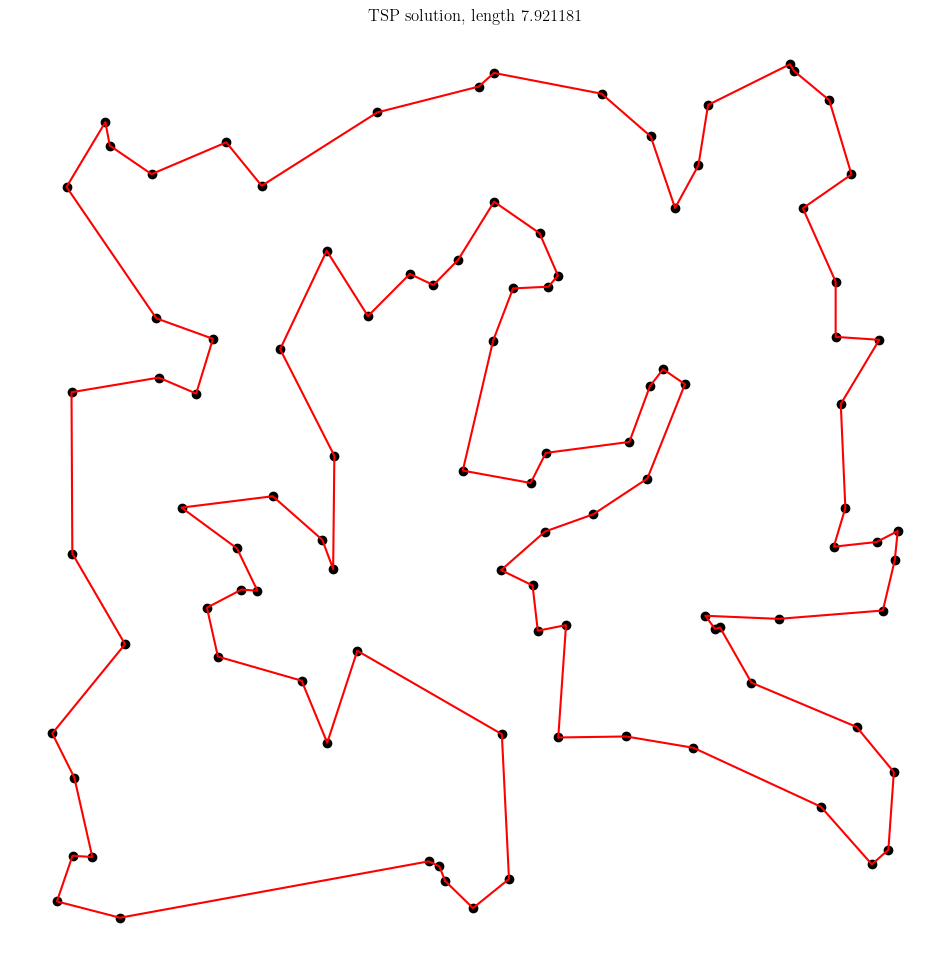

[89 58 52 91 47  2 93 65 64 14 62 97 44 80 57 56 50 96 49  8 81 95 59 20
 99 23 55 26 15 51 67 38 69 16  7 10 37  6 34 73 40 41 72  1  4  5 18 17
 98 39 77 24 78 48 71 25 63 61  3 19 13 82 53 35 22 32 31 84 27 43 86  9
 85 88 12 33 66 70 21 87 79 76 74  0 90 30 94 45 54 75 28 42 46 60 68 83
 92 36 29 11]


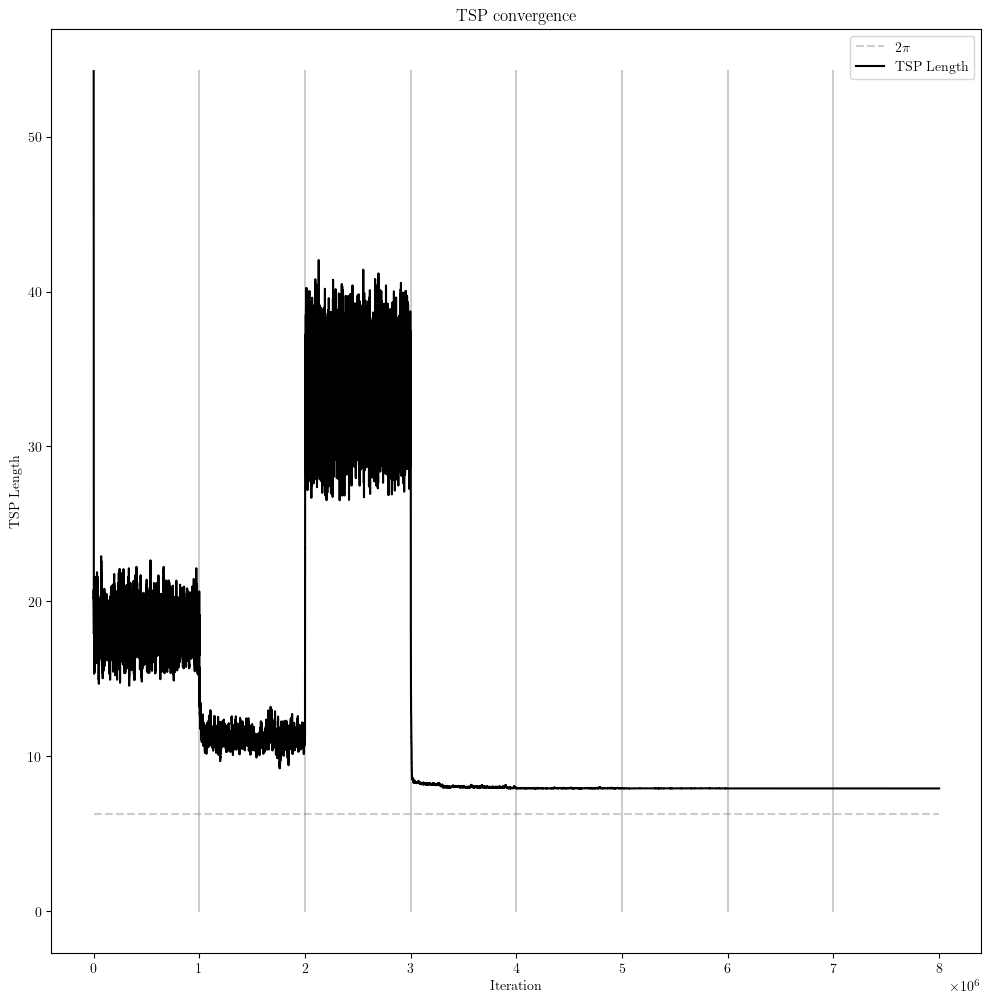

In [13]:

simulated_annealing_improved(nodes=nodes)

Annealing progress: |=======================================-| 100.00% Complete (T=0.0001)

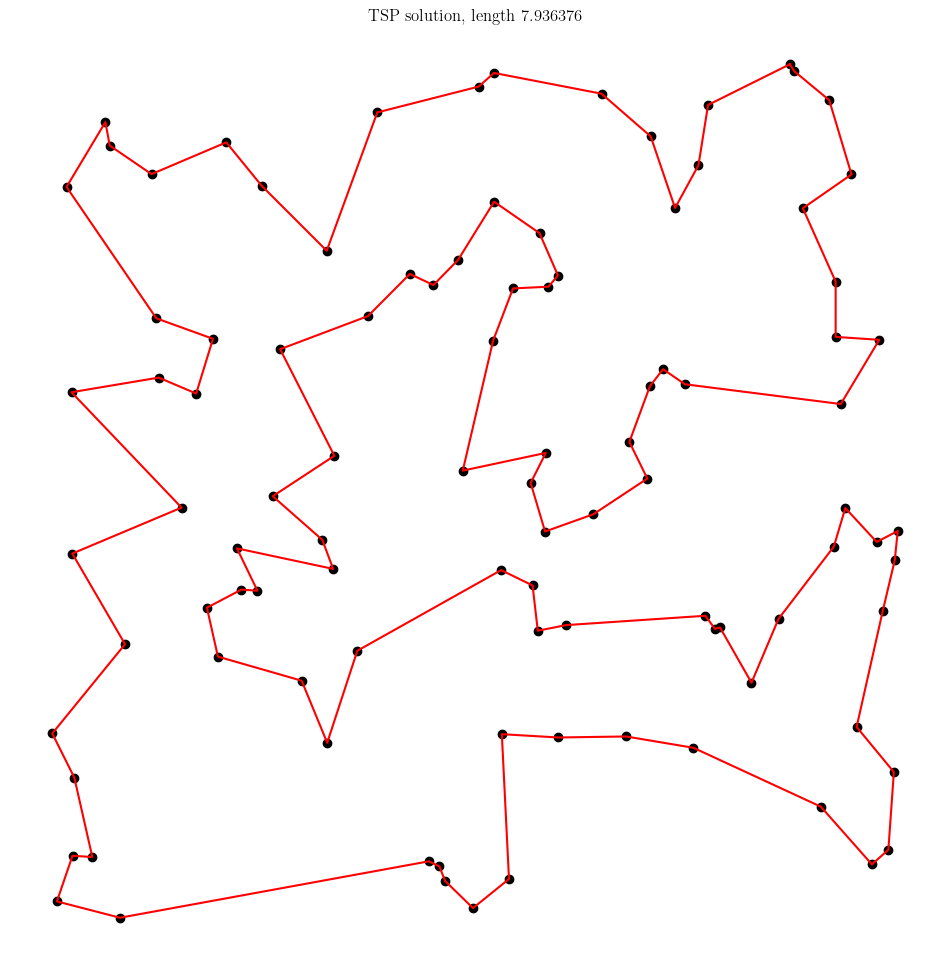

[67 38 69 16  7 10 37  6 34 32 31 84 27 22 35 53 86 43  9 85 88 12 33 66
 70 21 87 79 76  0 90 45 94 30 75 28 42 46 60 68 83 92 82 13 19  3 18 17
 98 39  5 40 73 41 72  1  4 77 24 78 48 71 25 63 61 36 29 11 89 58 52 91
 47  2 93 65 64 14 62 54 97 44 80 57 56 50 96 49  8 81 95 74 59 20 99 23
 55 26 15 51]


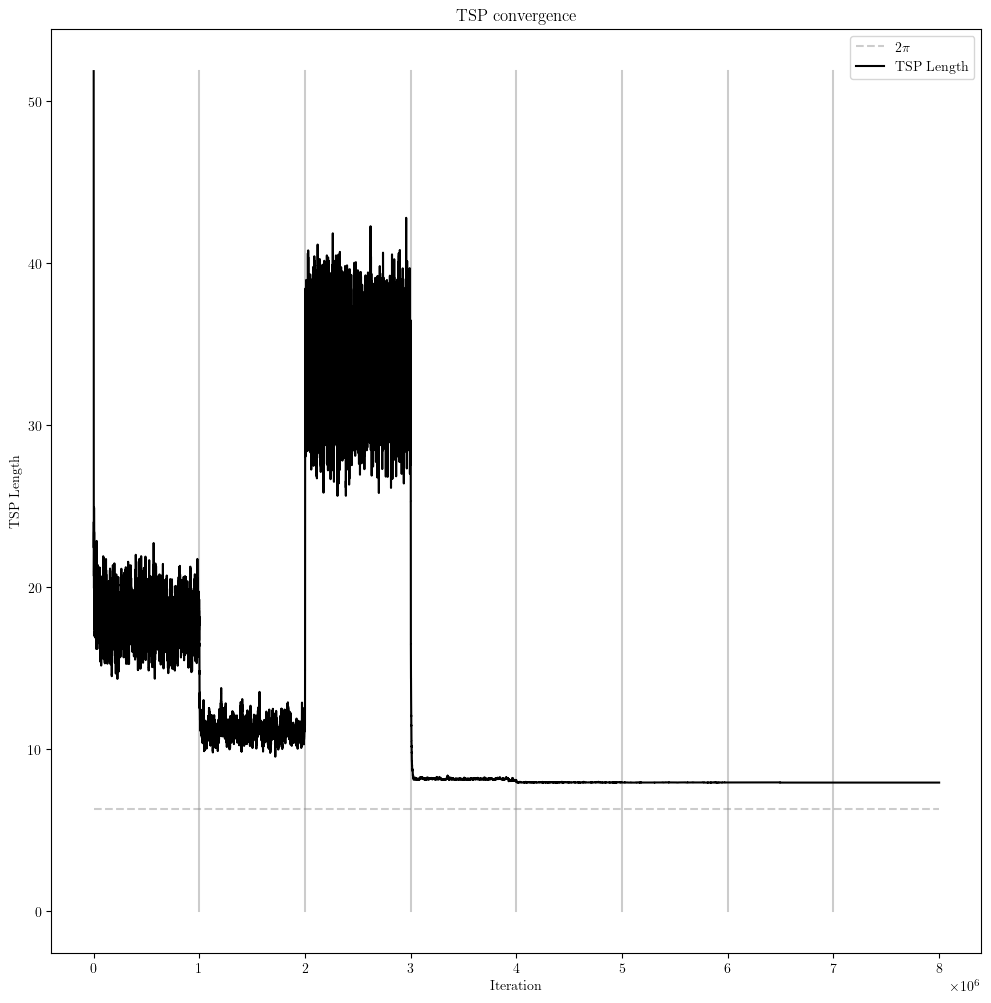

In [14]:
simulated_annealing_improved(nodes=nodes)

## Time-Dependent Simulated Annealing
stationary tsp -> time-dependent tsp:
change metric to include traffic jam area where the ts is slow after time step $M$

In [17]:
# implement time-dependent algorithm
def simulated_annealing_time_dependent(
        nodes : np.ndarray, 
        temperatures = [0.1, 0.01, 0.001], 
        repetitions = 10000, 
        want_plot=True,
        f : float = 0.5, 
        M : int = 5, 
        traffic_jam_area : np.ndarray = np.array([[xmin:=0.25, xmax:=0.75], [ymin:=0.25, ymax:=0.75]])
        ) -> None:
    """
    simulated annealing algorithm for the time-dependent traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = metric_time_dep_vectorized(
        node_coordinates=nodes,
        distance_matrix=D,
        permutation=current_perm,
        f=f,
        M=M,
        traffic_jam_area=traffic_jam_area
    )  # time dependent metric (only difference to previous function)

    temperature_step = 0  # for loading bar
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # calculate corresponding length
                trial_length = metric_time_dep_vectorized(
                node_coordinates=nodes,
                distance_matrix=D,
                permutation=trial_perm,
                f=f,
                M=M,
                traffic_jam_area=traffic_jam_area
                )   # time dependent metric (only difference to previous function)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 

                length_arr.append(current_length)
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # plot traffic jam area
        rectangle = plt.Rectangle(
            (traffic_jam_area[0,0], traffic_jam_area[1,0]),
            traffic_jam_area[0,1] - traffic_jam_area[0,0],
            traffic_jam_area[1,1] - traffic_jam_area[1,0],
            color='gray',
            alpha=0.3,
            label='Traffic Jam Area'
        )
        plt.gca().add_artist(rectangle)
        # label start point
        plt.text(
            nodes[current_perm[0], 0] + 0.02,
            nodes[current_perm[0], 1] + 0.02,
            'Start',
            fontsize=12,
            fontweight='bold',
            color='blue',
            ha='right',
            va='bottom'
        )
        
        # tour
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()


Annealing progress: |----------------------------------------| 0.00% Complete (T=0.1)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

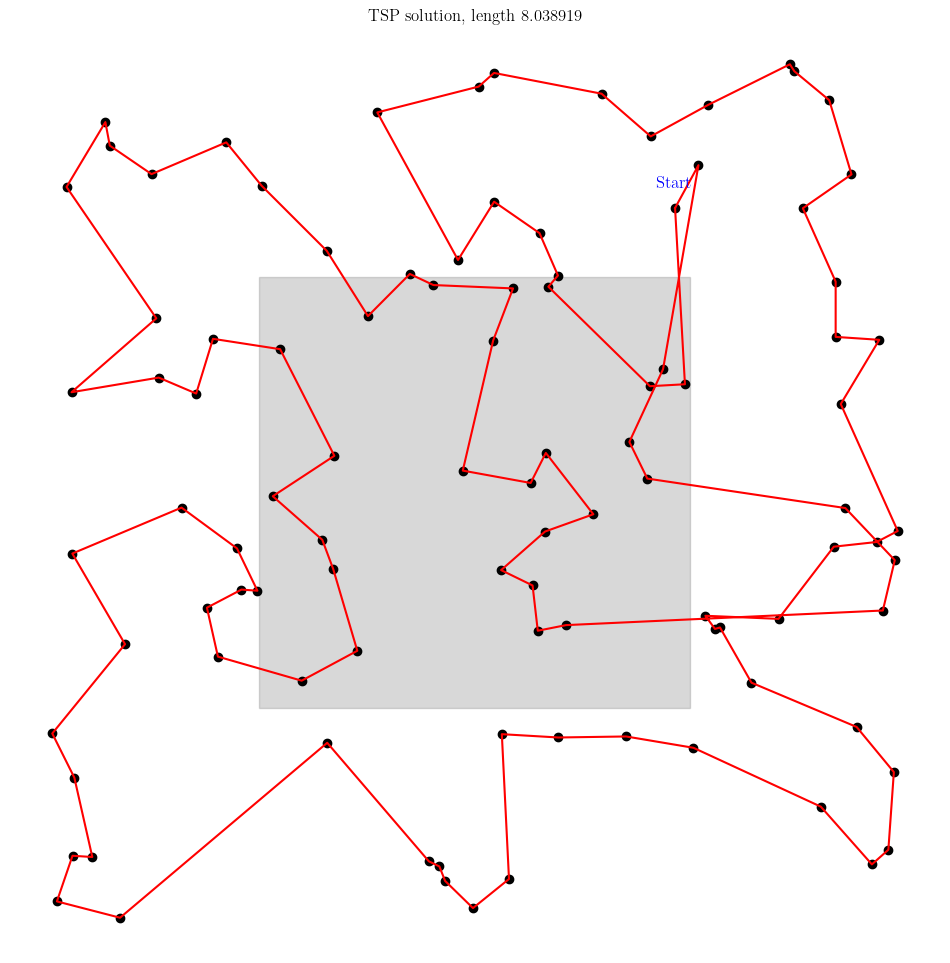

[26 32 84 12 33 66 70 21 59 20 99 23 55 51 67 38 69 16  7 10 37  6 34 72
 41 40  5 18 17 98 39 77 24 78 48 71 25 63 61 36 29 11 89 58 52 83 91 47
  2 93 65 64 14 62 54 75 28 42 46 60 68 92 30 94 45 90  0 57 80 44 97 56
 50 96 49  8 81 95 74 76 79 87 88 85  9 86 43 35 53 82 13 19  3  4  1 73
 22 27 31 15]


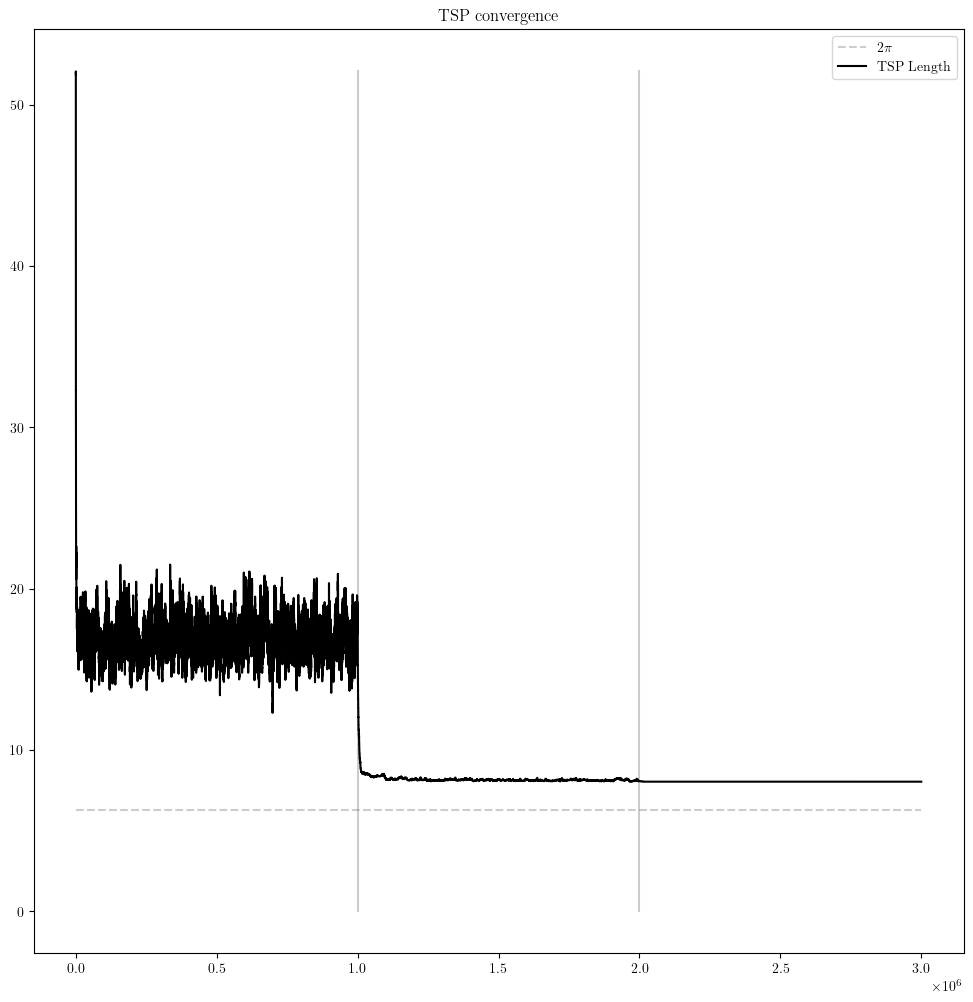

In [18]:
# try time dependent TSP on random points in unit square
simulated_annealing_time_dependent(nodes=nodes)